# Lieferverzögerungen – Explorative Datenanalyse

## Zusammenfassung der wichtigsten Ergebnisse

Die explorative Datenanalyse untersucht, welche Merkmale mit dem Auftreten von Lieferverzögerungen zusammenhängen. Zusätzlich wurden auf Basis der vorhandenen Variablen neue Merkmale entwickelt und auf ihren möglichen Informationsgehalt geprüft.

### Zentrale Ergebnisse

| Merkmal | Ergebnis | Entscheidung |
|---|---|---|
| Streckenlänge | Verspätungsquote steigt mit längerer Strecke | Beibehalten |
| Paketgewicht | Kaum Unterschied zwischen verspäteten und pünktlichen Lieferungen | Beibehalten / im Modell testen |
| Wetter | Deutlicher Zusammenhang, besonders bei Schnee und Sturm | Beibehalten |
| Verkehrsprognose | Hoher Verkehr zeigt deutlich höhere Verspätungsquote | Beibehalten |
| Versprochene Zustellzeit | Kurze Zustellfristen sind deutlich häufiger verspätet | Beibehalten |
| Tageszeit | Kein klarer Zusammenhang | Verworfen |
| Monat | Kein klares saisonales Muster | Verworfen |
| `hohes_risiko` | Rund 59,1 % verspätet | Neues Feature beibehalten |
| `km_pro_stunde` | Verspätungsquote steigt von ca. 20,7 % auf 43,3 % | Neues Feature beibehalten |
| `enge_lieferung_hoher_verkehr` | Rund 58,6 % verspätet | Neues Feature beibehalten |

### Fazit

Die stärksten Zusammenhänge mit Lieferverzögerungen zeigen sich bei ungünstigen Wetterbedingungen, hohem Verkehrsaufkommen, längeren Strecken und kurzen bzw. anspruchsvollen Zustellfristen. Besonders auffällig sind Kombinationen mehrerer Risikofaktoren, bei denen die Verspätungsquote auf rund 59 % steigt.

Auf Basis der EDA wurden daher zusätzliche Merkmale entwickelt, die diese Zusammenhänge abbilden. Merkmale ohne erkennbaren zusätzlichen Informationsgewinn, wie Tageszeit oder Monat, wurden nicht in den finalen ML-Datensatz übernommen.

In [205]:
import pandas as pd

df = pd.read_csv("lieferungen_cleaned.csv")

In [206]:
# Anzahl und Anteil pünktlicher und verspäteter Lieferungen

anzahl = df["verspaetet"].value_counts().sort_index()
anteil = df["verspaetet"].value_counts(normalize=True).sort_index() * 100

print("Anzahl:")
print(anzahl)

print("\nAnteil in %:")
print(anteil.round(2))

Anzahl:
verspaetet
0    8440
1    3584
Name: count, dtype: int64

Anteil in %:
verspaetet
0    70.19
1    29.81
Name: proportion, dtype: float64


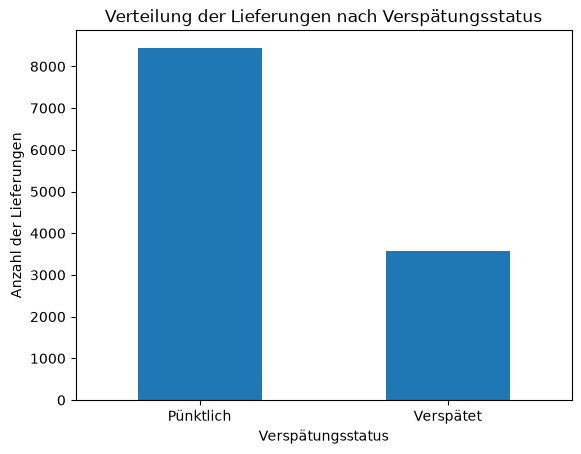

In [207]:
import matplotlib.pyplot as plt

anzahl.plot(kind="bar")

plt.title("Verteilung der Lieferungen nach Verspätungsstatus")
plt.xlabel("Verspätungsstatus")
plt.ylabel("Anzahl der Lieferungen")
plt.xticks([0, 1], ["Pünktlich", "Verspätet"], rotation=0)

plt.show()

### Ergebnis

Von insgesamt 12.024 Lieferungen wurden 8.440 (70,19 %) pünktlich und 3.584 (29,81 %) verspätet zugestellt.

Die Zielvariable ist damit ungleich verteilt, wobei verspätete Lieferungen mit knapp 30 % dennoch einen relevanten Anteil des Datensatzes ausmachen.

In [208]:
## Streckenlänge (`strecke_km`)
df["strecke_km"].describe()

count    12024.000000
mean        80.073187
std         80.082099
min          2.000000
25%         23.000000
50%         56.000000
75%        111.000000
max        700.000000
Name: strecke_km, dtype: float64

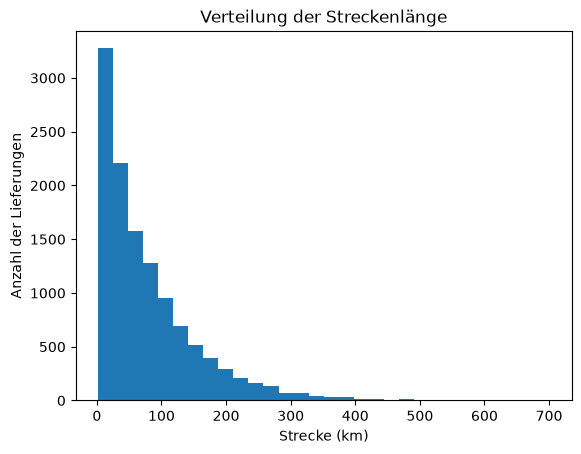

In [209]:
plt.hist(df["strecke_km"], bins=30)

plt.title("Verteilung der Streckenlänge")
plt.xlabel("Strecke (km)")
plt.ylabel("Anzahl der Lieferungen")

plt.show()

### Ergebnis

Die Streckenlänge ist deutlich rechtsschief verteilt. Die meisten Lieferungen erfolgen über kürzere Distanzen, während wenige Lieferungen sehr lange Strecken von bis zu 700 km aufweisen.

Der Median liegt bei 56 km und damit deutlich unter dem Mittelwert von rund 80 km. Die langen Strecken ziehen den Mittelwert nach oben.

In [210]:
## Sind längere Strecken häufiger verspätet als kürzere?
df.groupby("verspaetet")["strecke_km"].describe()

,count,mean,std,min,25%,50%,75%,max
verspaetet,,,,,,,,
0,8440.0,71.860664,70.576935,2.0,21.0,49.0,101.0,624.0
1,3584.0,99.412946,96.201843,2.0,30.0,72.0,137.0,700.0


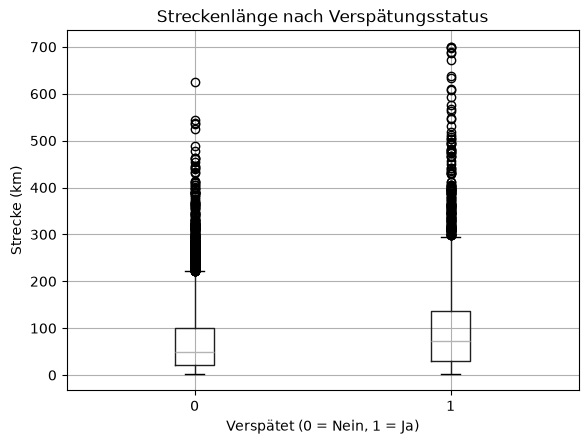

In [211]:
df.boxplot(column="strecke_km", by="verspaetet")

plt.xlabel("Verspätet (0 = Nein, 1 = Ja)")
plt.ylabel("Strecke (km)")
plt.title("Streckenlänge nach Verspätungsstatus")
plt.suptitle("")
plt.show()

### Streckenlänge nach Verspätungsstatus

Verspätete Lieferungen weisen tendenziell längere Strecken auf als nicht verspätete Lieferungen. Die mittlere Streckenlänge beträgt bei nicht verspäteten Lieferungen rund 72 km, bei verspäteten Lieferungen rund 99 km. Auch der Median liegt bei verspäteten Lieferungen mit 72 km deutlich über dem Median von 49 km bei nicht verspäteten Lieferungen.

Der Boxplot bestätigt diesen Unterschied: Median und Quartile liegen bei verspäteten Lieferungen höher. Die Streckenlänge könnte daher ein relevantes Merkmal für die Vorhersage von Verspätungen sein.

**Hinweis zu Ausreißern:** Die hohen Streckenwerte werden beibehalten. Obwohl sie im Boxplot als Ausreißer erscheinen, können längere Lieferstrecken fachlich plausibel sein und sind daher nicht automatisch als fehlerhafte Daten zu betrachten.

Dies deutet darauf hin, dass die Streckenlänge mit dem Auftreten von Verspätungen
zusammenhängen könnte.

In [212]:
df.columns

Index(['Unnamed: 0', 'lieferung_id', 'abhol_datum', 'abhol_wochentag',
       'abhol_zeit_uhr', 'start_plz', 'ziel_plz', 'strecke_km',
       'paket_groesse', 'paket_gewicht_kg', 'fahrzeug_typ', 'fahrer_id',
       'fahrer_erfahrung_jahre', 'wetter', 'verkehr_prognose',
       'versprochene_zustellung_stunden', 'verspaetet', 'wochentag_neu'],
      dtype='str')

In [213]:
df["paket_gewicht_kg"].describe()

count    12024.000000
mean        13.727137
std         93.464009
min          0.000000
25%          2.800000
50%          4.800000
75%         17.100000
max       9999.000000
Name: paket_gewicht_kg, dtype: float64

In [214]:
## Wie oft Extreme vorkommen
df["paket_gewicht_kg"].sort_values(ascending=False).head(20)

5726     9999.0
3289     1500.0
11348     101.2
7091      101.0
6538      101.0
2824       95.9
10154      90.8
223        89.6
995        88.3
1551       86.8
8428       86.8
7273       86.7
2007       86.6
850        86.4
11094      86.3
9120       86.0
2097       85.0
5649       84.6
7485       84.2
2996       83.8
Name: paket_gewicht_kg, dtype: float64

In [215]:
df.loc[[5726, 3289]]

,Unnamed: 0,lieferung_id,abhol_datum,abhol_wochentag,abhol_zeit_uhr,start_plz,ziel_plz,strecke_km,paket_groesse,paket_gewicht_kg,fahrzeug_typ,fahrer_id,fahrer_erfahrung_jahre,wetter,verkehr_prognose,versprochene_zustellung_stunden,verspaetet,wochentag_neu
5726,5727,LF-005727,2025-08-18,Mo,15:00:00,33329,79404,331,Klein,9999.0,Transporter,FA-821,1.0,sonnig,hoch,8,1,Mo
3289,3290,LF-003290,2024-07-28,So,07:00:00,95919,55697,60,Klein,1500.0,Transporter,FA-376,5.0,regen,mittel,24,1,So


Hier können wir die beiden Werte fachlich als fehlerhafte Einträge behandeln. Ein Paket der Größe „Klein“ mit 9.999 kg bzw. 1.500 kg ist nicht plausibel; beim 9.999-kg-Fall kommt zusätzlich ein Transporter als Fahrzeug hinzu. Das spricht sehr stark für Eingabefehler bzw. fehlerhafte Sonderwerte.

In [216]:
## Werte auf NaN
import numpy as np

df.loc[df["paket_gewicht_kg"].isin([9999, 1500]), "paket_gewicht_kg"] = np.nan
df["paket_gewicht_kg"].describe()

count    12022.000000
mean        12.772925
std         16.062700
min          0.000000
25%          2.800000
50%          4.800000
75%         17.100000
max        101.200000
Name: paket_gewicht_kg, dtype: float64

In [217]:
df.groupby("paket_groesse")["paket_gewicht_kg"].agg(["count", "median", "mean", "min", "max"])

,count,median,mean,min,max
paket_groesse,,,,,
Gross,1798,44.35,44.023971,0.2,101.2
Klein,6578,3.00,3.017148,0.2,8.4
Mittel,3646,15.05,14.962754,0.0,35.8


In [218]:
## Imputieren der fehlenden Werte mit dem Median der jeweiligen Paketgröße
df["paket_gewicht_kg"] = df["paket_gewicht_kg"].fillna(
    df.groupby("paket_groesse")["paket_gewicht_kg"].transform("median")
)

df["paket_gewicht_kg"].isna().sum()

np.int64(0)

In [219]:
## Zusammenhang zwischen Paketgewicht und Verspätung
df.groupby("verspaetet")["paket_gewicht_kg"].describe()

,count,mean,std,min,25%,50%,75%,max
verspaetet,,,,,,,,
0,8440.0,12.716552,16.152967,0.0,2.8,4.7,17.0,101.2
1,3584.0,12.900223,15.846726,0.2,2.8,5.1,17.3,86.8


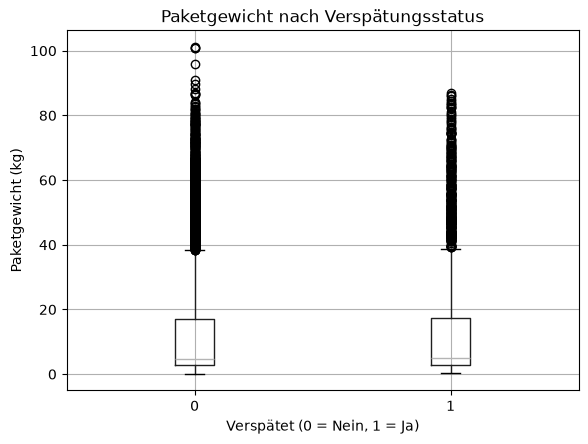

In [220]:
df.boxplot(column="paket_gewicht_kg", by="verspaetet")

plt.xlabel("Verspätet (0 = Nein, 1 = Ja)")
plt.ylabel("Paketgewicht (kg)")
plt.title("Paketgewicht nach Verspätungsstatus")
plt.suptitle("")
plt.show()

### Ergebnis: Paketgewicht und Verspätungsstatus

Bei der Prüfung des Paketgewichts wurden zwei offensichtlich fehlerhafte Werte von 1.500 kg und 9.999 kg identifiziert. Da beide Sendungen als Paketgröße „Klein“ klassifiziert waren, wurden die fehlerhaften Werte zunächst als fehlend markiert und anschließend mit dem Median der jeweiligen Paketgröße imputiert. Für kleine Pakete beträgt dieser Median 3,0 kg.

Beim Vergleich des Paketgewichts nach Verspätungsstatus zeigen sich nur geringe Unterschiede. Nicht verspätete Lieferungen haben ein durchschnittliches Gewicht von rund 12,72 kg und einen Median von 4,7 kg. Bei verspäteten Lieferungen liegen der Mittelwert bei rund 12,90 kg und der Median bei 5,1 kg.

Auch der Boxplot zeigt sehr ähnliche Verteilungen in beiden Gruppen. Ein deutlicher Zusammenhang zwischen Paketgewicht und Verspätungsstatus ist daher in der explorativen Analyse nicht erkennbar.

Die übrigen hohen Gewichte werden beibehalten, da sie insbesondere bei großen Paketen plausibel sind und nicht automatisch als fehlerhafte Ausreißer betrachtet werden können.

In [221]:

## wie die drei Paketgrößen im Datensatz verteilt sind
df["paket_groesse"].value_counts()

paket_groesse
Klein     6580
Mittel    3646
Gross     1798
Name: count, dtype: int64

In [222]:
## Unterscheidet sich die Verspätungsquote nach Paketgröße?
pd.crosstab(
    df["paket_groesse"],
    df["verspaetet"],
    normalize="index"
) * 100

verspaetet,0,1
paket_groesse,,
Gross,70.244716,29.755284
Klein,71.094225,28.905775
Mittel,68.540867,31.459133


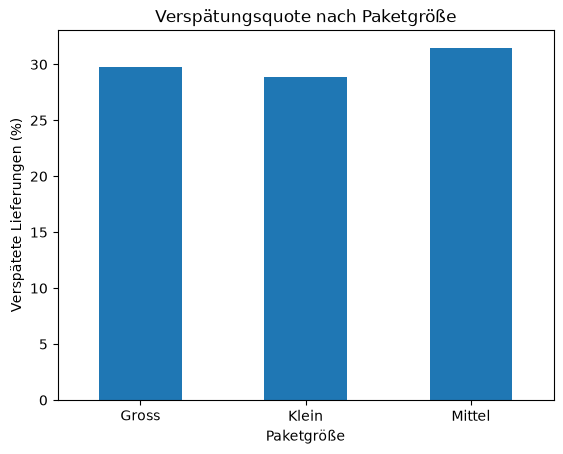

In [223]:
verspaetungsquote = (
    df.groupby("paket_groesse")["verspaetet"]
    .mean() * 100
)

verspaetungsquote.plot(kind="bar")

plt.xlabel("Paketgröße")
plt.ylabel("Verspätete Lieferungen (%)")
plt.title("Verspätungsquote nach Paketgröße")
plt.xticks(rotation=0)
plt.show()

### Ergebnis: Paketgröße und Verspätungsstatus

Die Verspätungsquoten unterscheiden sich zwischen den Paketgrößen nur geringfügig. Mittlere Pakete weisen mit rund 31,5 % die höchste Verspätungsquote auf, gefolgt von großen Paketen mit rund 29,8 % und kleinen Paketen mit rund 28,9 %.

Die Unterschiede sind insgesamt klein. In der explorativen Analyse ist daher kein deutlicher Zusammenhang zwischen Paketgröße und Verspätungsstatus erkennbar.

In [224]:
df["fahrzeug_typ"].value_counts()

fahrzeug_typ
Transporter    6678
Lkw (Klein)    3494
Lkw (Gross)    1852
Name: count, dtype: int64

In [225]:
## Verspätungsquote innerhalb jedes Fahrzeugtyps
pd.crosstab(
    df["fahrzeug_typ"],
    df["verspaetet"],
    normalize="index"
) * 100

verspaetet,0,1
fahrzeug_typ,,
Lkw (Gross),69.438445,30.561555
Lkw (Klein),69.433314,30.566686
Transporter,70.799641,29.200359


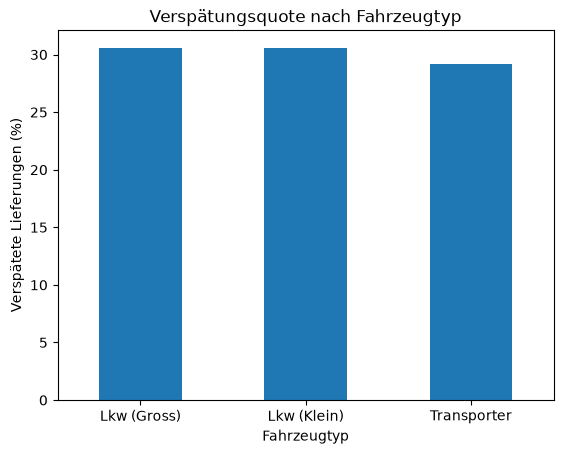

In [226]:
verspaetungsquote_fahrzeug = (
    df.groupby("fahrzeug_typ")["verspaetet"]
    .mean() * 100
)

verspaetungsquote_fahrzeug.plot(kind="bar")

plt.xlabel("Fahrzeugtyp")
plt.ylabel("Verspätete Lieferungen (%)")
plt.title("Verspätungsquote nach Fahrzeugtyp")
plt.xticks(rotation=0)
plt.show()

### Ergebnis: Fahrzeugtyp und Verspätungsstatus

Die Verspätungsquoten unterscheiden sich zwischen den Fahrzeugtypen nur geringfügig. Bei großen und kleinen Lkw liegt die Verspätungsquote jeweils bei rund 30,6 %, bei Transportern bei rund 29,2 %.

Die Werte sind damit nahezu identisch. In der explorativen Analyse ist kein deutlicher Zusammenhang zwischen Fahrzeugtyp und Verspätungsstatus erkennbar.

In [227]:
df["wetter"].value_counts(dropna=False)

wetter
sonnig      4728
bewoelkt    3582
regen       2315
sturm        584
schnee       575
NaN          240
Name: count, dtype: int64

In [228]:
df[df["wetter"].isna()][
    ["abhol_datum", "abhol_wochentag", "abhol_zeit_uhr",
     "start_plz", "ziel_plz", "wetter"]
].head(20)

,abhol_datum,abhol_wochentag,abhol_zeit_uhr,start_plz,ziel_plz,wetter
32,2025-04-19,Sa,07:00:00,18601,83873,NaN
174,2024-08-12,Mo,18:00:00,48283,9725,NaN
184,2025-02-14,Fr,10:00:00,24036,87797,NaN
193,2025-02-11,So,16:00:00,3488,41117,NaN
338,2024-02-18,So,06:00:00,93482,77291,NaN
403,2025-07-28,Mo,09:00:00,18773,31164,NaN
463,2025-11-27,Do,17:00:00,67913,88556,NaN
495,2025-04-19,Sa,16:00:00,20971,6674,NaN
526,2025-05-15,Do,13:00:00,17977,63538,NaN
595,2024-08-22,Do,17:00:00,71265,35760,NaN


In [229]:
df[df["wetter"].isna()]["verspaetet"].value_counts(normalize=True) * 100

verspaetet
0    70.833333
1    29.166667
Name: proportion, dtype: float64

Die fehlenden Wetterwerte weisen mit 29,17 % eine nahezu identische Verspätungsquote wie der Gesamtdatensatz (29,81 %) auf und zeigen somit keine auffällige Abweichung hinsichtlich der Zielvariable. Daher wurden die fehlenden Wetterangaben als eigene Kategorie „Unbekannt“ beibehalten, anstatt eine nicht belegbare Wetterlage zu imputieren.

In [230]:
df["wetter"] = df["wetter"].fillna("Unbekannt")
df["wetter"].value_counts(dropna=False)

wetter
sonnig       4728
bewoelkt     3582
regen        2315
sturm         584
schnee        575
Unbekannt     240
Name: count, dtype: int64

In [231]:
## Wetter und Verspätungsstatus
pd.crosstab(
    df["wetter"],
    df["verspaetet"],
    normalize="index"
) * 100

verspaetet,0,1
wetter,,
Unbekannt,70.833333,29.166667
bewoelkt,75.376884,24.623116
regen,62.678186,37.321814
schnee,45.739130,54.260870
sonnig,75.994078,24.005922
sturm,45.034247,54.965753


In [232]:
wetter_quote = df.groupby("wetter")["verspaetet"].mean() * 100
wetter_quote

wetter
Unbekannt    29.166667
bewoelkt     24.623116
regen        37.321814
schnee       54.260870
sonnig       24.005922
sturm        54.965753
Name: verspaetet, dtype: float64

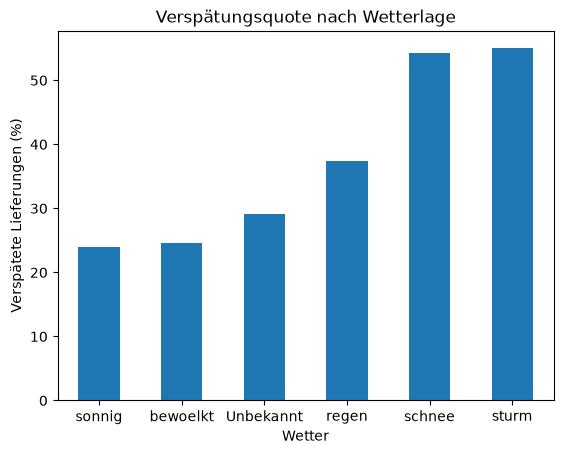

In [233]:
wetter_quote = wetter_quote.sort_values()

wetter_quote.plot(kind="bar")

plt.xlabel("Wetter")
plt.ylabel("Verspätete Lieferungen (%)")
plt.title("Verspätungsquote nach Wetterlage")
plt.xticks(rotation=0)
plt.show()

### Ergebnis: Wetterlage und Verspätungsstatus

Die Verspätungsquote unterscheidet sich deutlich nach Wetterlage. Bei sonnigem und bewölktem Wetter liegt sie bei rund 24 %, bei Regen steigt sie auf rund 37 %. Besonders hoch ist die Verspätungsquote bei Schnee (54,3 %) und Sturm (55,0 %).

Damit zeigt sich in der explorativen Analyse ein deutlicher Zusammenhang zwischen ungünstigen Wetterbedingungen und dem Auftreten von Verspätungen. Die Wetterlage könnte daher ein relevantes Merkmal für die Vorhersage von Lieferverzögerungen sein.

Die Kategorie „Unbekannt“ liegt mit rund 29,2 % nahe an der Verspätungsquote des Gesamtdatensatzes.

In [234]:
df["verkehr_prognose"].value_counts(dropna=False)

verkehr_prognose
niedrig    4850
mittel     4801
hoch       2373
Name: count, dtype: int64

In [235]:
## Verspätungsquote innerhalb jeder Verkehrskategorie
pd.crosstab(
    df["verkehr_prognose"],
    df["verspaetet"],
    normalize="index"
) * 100

verspaetet,0,1
verkehr_prognose,,
hoch,55.625790,44.374210
mittel,73.088940,26.911060
niedrig,74.453608,25.546392


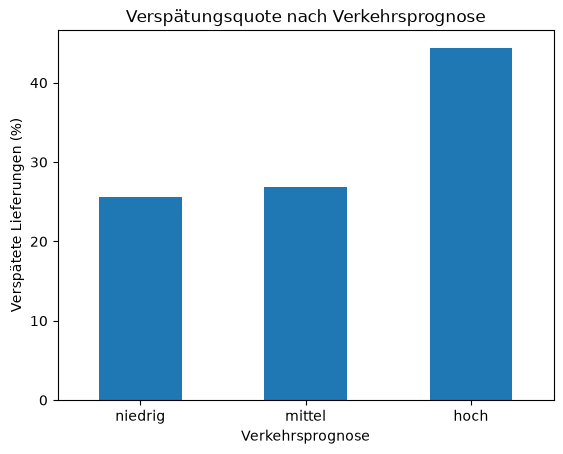

In [236]:
verkehr_quote = (
    df.groupby("verkehr_prognose")["verspaetet"].mean() * 100
)

verkehr_quote = verkehr_quote.sort_values()

verkehr_quote.plot(kind="bar")

plt.xlabel("Verkehrsprognose")
plt.ylabel("Verspätete Lieferungen (%)")
plt.title("Verspätungsquote nach Verkehrsprognose")
plt.xticks(rotation=0)
plt.show()

### Ergebnis: Verkehrsprognose und Verspätungsstatus

Bei niedriger und mittlerer Verkehrsprognose liegt die Verspätungsquote mit rund 25,5 % bzw. 26,9 % auf einem ähnlichen Niveau. Bei hoher Verkehrsprognose steigt sie dagegen deutlich auf rund 44,4 %.

Die explorative Analyse zeigt damit einen deutlichen Zusammenhang zwischen hohem Verkehrsaufkommen und dem Auftreten von Verspätungen. Die Verkehrsprognose könnte daher ein relevantes Merkmal für die Vorhersage von Lieferverzögerungen sein.

In [237]:
df["versprochene_zustellung_stunden"].describe()

count    12024.000000
mean        23.013972
std         14.899943
min          4.000000
25%          8.000000
50%         24.000000
75%         24.000000
max         48.000000
Name: versprochene_zustellung_stunden, dtype: float64

In [238]:
df["versprochene_zustellung_stunden"].value_counts().sort_index()

versprochene_zustellung_stunden
4     1164
8     3033
24    5329
48    2498
Name: count, dtype: int64

In [239]:
## Verspätungsquote je versprochener Zustellzeit
pd.crosstab(
    df["versprochene_zustellung_stunden"],
    df["verspaetet"],
    normalize="index"
) * 100

verspaetet,0,1
versprochene_zustellung_stunden,,
4,55.756014,44.243986
8,64.193867,35.806133
24,74.741978,25.258022
48,74.499600,25.500400


Je kürzer das versprochene Zustellfenster, desto höher ist tendenziell die Verspätungsquote.

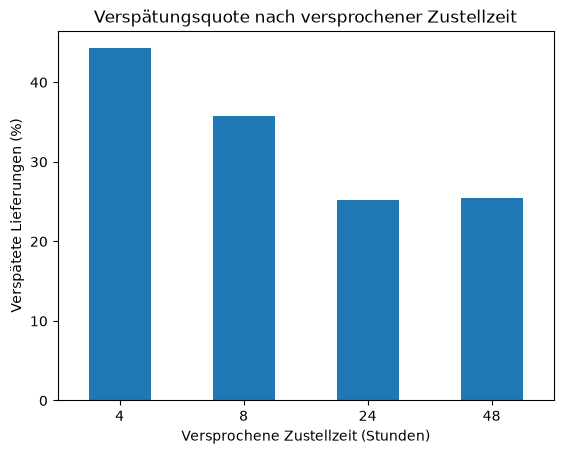

In [240]:
zustellung_quote = (
    df.groupby("versprochene_zustellung_stunden")["verspaetet"]
    .mean() * 100
)

zustellung_quote.plot(kind="bar")

plt.xlabel("Versprochene Zustellzeit (Stunden)")
plt.ylabel("Verspätete Lieferungen (%)")
plt.title("Verspätungsquote nach versprochener Zustellzeit")
plt.xticks(rotation=0)
plt.show()

### Ergebnis: Versprochene Zustellzeit und Verspätungsstatus

Die Verspätungsquote ist bei kurzen versprochenen Zustellzeiten deutlich höher. Bei einer Zustellzeit von 4 Stunden sind rund 44,2 % der Lieferungen verspätet, bei 8 Stunden rund 35,8 %. Bei 24 und 48 Stunden liegt die Verspätungsquote dagegen nahezu identisch bei rund 25,3 % bzw. 25,5 %.

Die explorative Analyse zeigt damit einen deutlichen Zusammenhang zwischen kurzen Zustellfristen und dem Auftreten von Verspätungen. Die versprochene Zustellzeit könnte daher ein relevantes Merkmal für die Vorhersage von Lieferverzögerungen sein.

In [241]:
df["abhol_zeit_uhr"].value_counts().sort_index()

abhol_zeit_uhr
06:00:00     605
07:00:00     918
08:00:00    1221
09:00:00    1225
10:00:00    1132
11:00:00     944
12:00:00     844
13:00:00     851
14:00:00     743
15:00:00     726
16:00:00     675
17:00:00     589
18:00:00     595
19:00:00     490
20:00:00     466
Name: count, dtype: int64

In [242]:
## Verspätungsquote pro Abholzeit
zeit_quote = (
    df.groupby("abhol_zeit_uhr")["verspaetet"]
    .mean() * 100
)

zeit_quote

abhol_zeit_uhr
06:00:00    30.743802
07:00:00    31.808279
08:00:00    28.746929
09:00:00    30.775510
10:00:00    28.268551
11:00:00    31.567797
12:00:00    29.502370
13:00:00    31.022327
14:00:00    27.994616
15:00:00    26.997245
16:00:00    27.851852
17:00:00    30.050934
18:00:00    33.109244
19:00:00    28.979592
20:00:00    29.828326
Name: verspaetet, dtype: float64

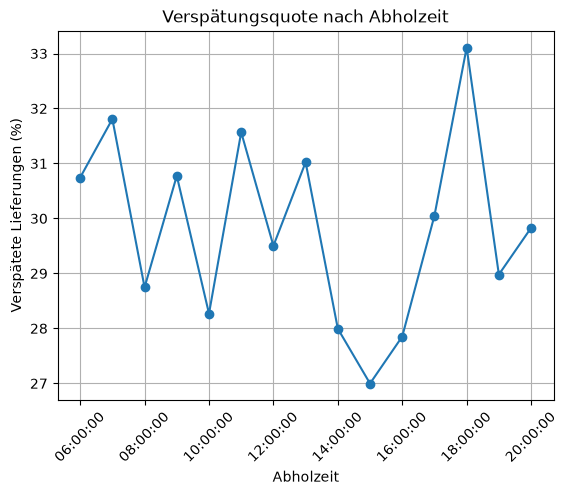

In [243]:
zeit_quote.plot(kind="line", marker="o")

plt.xlabel("Abholzeit")
plt.ylabel("Verspätete Lieferungen (%)")
plt.title("Verspätungsquote nach Abholzeit")
plt.xticks(rotation=45)
plt.grid()
plt.show()

### Ergebnis: Abholzeit und Verspätungsstatus

Die Verspätungsquote schwankt je nach Abholzeit zwischen rund 27 % und 33 %. Die niedrigste Quote zeigt sich gegen 15 Uhr mit rund 27 %, die höchste gegen 18 Uhr mit rund 33 %.

Über den Tagesverlauf ist jedoch kein eindeutiger Trend erkennbar. Die Abholzeit zeigt in der explorativen Analyse daher keinen deutlichen Zusammenhang mit dem Verspätungsstatus.

In [244]:
df["wochentag_neu"].value_counts()

wochentag_neu
So    1772
Fr    1758
Di    1752
Mo    1706
Sa    1701
Do    1680
Mi    1655
Name: count, dtype: int64

In [245]:
## Verspätungsquote pro Wochentag
wochentag_quote = (
    df.groupby("wochentag_neu")["verspaetet"]
    .mean() * 100
)

wochentag_quote

wochentag_neu
Di    26.997717
Do    29.583333
Fr    34.641638
Mi    28.942598
Mo    28.956624
Sa    31.334509
So    28.160271
Name: verspaetet, dtype: float64

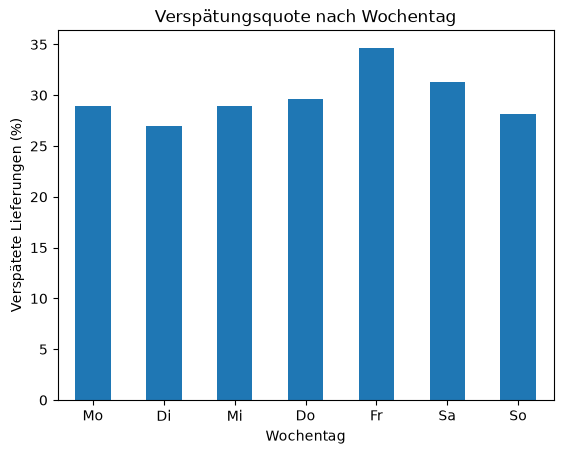

In [246]:
reihenfolge = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]

wochentag_quote = wochentag_quote.reindex(reihenfolge)

wochentag_quote.plot(kind="bar")

plt.xlabel("Wochentag")
plt.ylabel("Verspätete Lieferungen (%)")
plt.title("Verspätungsquote nach Wochentag")
plt.xticks(rotation=0)
plt.show()

### Ergebnis: Wochentag und Verspätungsstatus

Die Verspätungsquote variiert je nach Wochentag moderat. Die höchste Quote zeigt sich am Freitag mit rund 34,6 %, gefolgt vom Samstag mit rund 31,3 %. Am niedrigsten ist die Verspätungsquote am Dienstag mit rund 27,0 %.

Ein eindeutiger Wochenend-Effekt ist nicht erkennbar, da die Verspätungsquote am Sonntag mit rund 28,2 % vergleichsweise niedrig ist. Auffällig ist insbesondere der Freitag, insgesamt ist der Zusammenhang zwischen Wochentag und Verspätungsstatus jedoch schwächer als beispielsweise bei Wetterlage oder Verkehrsprognose.

In [247]:
df[["start_plz", "ziel_plz"]].dtypes


start_plz    int64
ziel_plz     int64
dtype: object

In [248]:
df[["start_plz", "ziel_plz"]].head(10)

,start_plz,ziel_plz
0,17524,68411
1,20032,59522
2,32501,34167
3,62692,81846
4,91577,68938
5,62164,69327
6,34666,48846
7,40810,71203
8,74197,70774
9,62969,6733


In [249]:
df["start_plz_str"] = df["start_plz"].astype(str).str.zfill(5)
df["ziel_plz_str"] = df["ziel_plz"].astype(str).str.zfill(5)

In [250]:
df[["start_plz", "start_plz_str", "ziel_plz", "ziel_plz_str"]].head(10)

,start_plz,start_plz_str,ziel_plz,ziel_plz_str
0,17524,17524,68411,68411
1,20032,20032,59522,59522
2,32501,32501,34167,34167
3,62692,62692,81846,81846
4,91577,91577,68938,68938
5,62164,62164,69327,69327
6,34666,34666,48846,48846
7,40810,40810,71203,71203
8,74197,74197,70774,70774
9,62969,62969,6733,06733


In [251]:
## Referenzdatei
with open("DE.txt", "r", encoding="utf-8") as f:
    for _ in range(10):
        print(f.readline().strip())

DE	10875	Daimler Brand und IP Management GmbH & Co.KG	Baden-Württemberg	01	Regierungsbezirk Stuttgart	081	Stadtkreis Stuttgart	08111	48.7239	9.1699
DE	10875	Mercedes-Benz Versicherung AG	Baden-Württemberg	01	Regierungsbezirk Stuttgart	081	Stadtkreis Stuttgart	08111	48.8103	9.1807
DE	10875	Mercedes-Benz Vertrieb NFZ GmbH	Baden-Württemberg	01	Regierungsbezirk Stuttgart	081	Stadtkreis Stuttgart	08111	48.7239	9.1699
DE	10875	Fünfte Vermögensverwaltungsgesellschaft Zeus mbH	Baden-Württemberg	01	Regierungsbezirk Stuttgart	081	Stadtkreis Stuttgart	08111	48.7239	9.1699
DE	10875	Mercedes-Benz. io GmbH	Baden-Württemberg	01	Regierungsbezirk Stuttgart	081	Stadtkreis Stuttgart	08111	48.7794	9.1679
DE	10875	Mercedes-Benz Vertrieb PKW GmbH	Baden-Württemberg	01	Regierungsbezirk Stuttgart	081	Stadtkreis Stuttgart	08111	48.7239	9.1699
DE	10875	LAB1886 GmbH	Baden-Württemberg	01	Regierungsbezirk Stuttgart	081	Stadtkreis Stuttgart	08111	48.7239	9.1699
DE	10875	Daimler Insurance Services GmbH	Baden-Württemb

In [252]:
## PLZ aus DE.txt
de_plz = pd.read_csv(
    "DE.txt",
    sep="\t",
    header=None,
    usecols=[1],
    dtype=str
)

de_plz.columns = ["plz"]

de_plz.head(10)

,plz
0,10875
1,10875
2,10875
3,10875
4,10875
5,10875
6,10875
7,10875
8,10875
9,11512


In [253]:
print("Zeilen in DE.txt:", len(de_plz))
print("Eindeutige PLZ:", de_plz["plz"].nunique())
print("Länge der PLZ:")
print(de_plz["plz"].str.len().value_counts().sort_index())

Zeilen in DE.txt: 23297
Eindeutige PLZ: 10813
Länge der PLZ:
plz
5    23297
Name: count, dtype: int64


In [254]:
## Wie viele PLZ aus dem Lieferdatensatz existieren tatsächlich in dieser deutschen Referenz?
gueltige_plz = set(de_plz["plz"])

print("Start-PLZ gültig:")
print(df["start_plz_str"].isin(gueltige_plz).value_counts())

print("\nZiel-PLZ gültig:")
print(df["ziel_plz_str"].isin(gueltige_plz).value_counts())

Start-PLZ gültig:
start_plz_str
False    10684
True      1340
Name: count, dtype: int64

Ziel-PLZ gültig:
ziel_plz_str
False    10714
True      1310
Name: count, dtype: int64


In [255]:
ungueltige_start = df.loc[
    ~df["start_plz_str"].isin(gueltige_plz),
    "start_plz_str"
]

print("Ungültige Start-PLZ insgesamt:", len(ungueltige_start))
print("Davon unterschiedliche PLZ:", ungueltige_start.nunique())
print("\nHäufigste ungültige Start-PLZ:")
print(ungueltige_start.value_counts().head(20))

Ungültige Start-PLZ insgesamt: 10684
Davon unterschiedliche PLZ: 10058

Häufigste ungültige Start-PLZ:
start_plz_str
63049    3
98624    3
22627    3
85536    3
38878    3
57203    3
12802    3
85384    3
99229    3
38607    3
40873    3
68468    3
77589    3
95923    3
56383    3
02718    3
06561    3
12756    3
68853    3
39456    3
Name: count, dtype: int64


In [256]:
## Sind die ungültigen PLZ vielleicht „fast richtig“?
ungueltige_ziel = df.loc[
    ~df["ziel_plz_str"].isin(gueltige_plz),
    "ziel_plz_str"
]

print("Ungültige Ziel-PLZ insgesamt:", len(ungueltige_ziel))
print("Davon unterschiedliche PLZ:", ungueltige_ziel.nunique())

print("\nHäufigste ungültige Ziel-PLZ:")
print(ungueltige_ziel.value_counts().head(20))

Ungültige Ziel-PLZ insgesamt: 10714
Davon unterschiedliche PLZ: 10030

Häufigste ungültige Ziel-PLZ:
ziel_plz_str
63248    4
13610    3
15139    3
92098    3
89740    3
44208    3
57128    3
87263    3
79337    3
68597    3
45515    3
01236    3
54315    3
31187    3
64495    3
82645    3
62989    3
87400    3
09519    3
30976    3
Name: count, dtype: int64


In [257]:
## Wie sind gültige und ungültige PLZ über die erste Ziffer verteilt?
## Deutsche PLZ haben geografisch strukturierte erste Ziffern von 0 bis 9.
## Wenn der Datensatz einfach zufällige fünfstellige Zahlen enthält, sollten wir das möglicherweise an der Verteilung erkennen.
plz_check_start = pd.DataFrame({
    "erste_ziffer": df["start_plz_str"].str[0],
    "gueltig": df["start_plz_str"].isin(gueltige_plz)
})

pd.crosstab(
    plz_check_start["erste_ziffer"],
    plz_check_start["gueltig"],
    normalize="index"
).round(3) * 100


gueltig,False,True
erste_ziffer,,
0,91.2,8.8
1,93.0,7.0
2,86.2,13.8
3,88.2,11.8
4,90.7,9.3
5,89.0,11.0
6,90.9,9.1
7,87.0,13.0
8,86.9,13.1


In [258]:
## Wie wahrscheinlich wäre überhaupt ein zufälliger Treffer?
print("Anteil der Referenz-PLZ am Zahlenraum 00000–99999:")
print(round(len(gueltige_plz) / 100000 * 100, 2), "%")

print("\nBeobachteter Anteil gültiger Start-PLZ:")
print(round(df["start_plz_str"].isin(gueltige_plz).mean() * 100, 2), "%")

print("\nBeobachteter Anteil gültiger Ziel-PLZ:")
print(round(df["ziel_plz_str"].isin(gueltige_plz).mean() * 100, 2), "%")

Anteil der Referenz-PLZ am Zahlenraum 00000–99999:
10.81 %

Beobachteter Anteil gültiger Start-PLZ:
11.14 %

Beobachteter Anteil gültiger Ziel-PLZ:
10.89 %


Observed-vs.-Expected-Vergleich durchgeführt. Von 100.000 möglichen fünfstelligen Zahlen entsprechen laut Referenzdatei rund 10,8 % einer realen deutschen PLZ. Wenn die rund 12.000 PLZ unseres Datensatzes zufällig generiert wären, würden daher ungefähr 1.300 zufällige Treffer erwartet. Tatsächlich beobachten wir 1.340 gültige Start-PLZ und 1.310 gültige Ziel-PLZ. Die beobachteten Werte liegen damit sehr nahe am zufällig erwarteten Wert.

Das ist ein starkes Indiz dafür, dass die PLZ synthetisch bzw. zufällig generiert wurden. Deshalb diese Spalten sind nicht verlässlich und wir sollen sie aus der weiteren Analyse bzw. dem Feature Engineering ausschliessen. Auch in realen Datensätzen können einzelne Spalten durch fehlerhafte Migrationen, Importe, Anonymisierung, Eingabefehler oder unterschiedliche Quellsysteme unzuverlässig bzw. unbrauchbar sein.


In [259]:
## Wie viele unterschiedliche Fahrer gibt es?
print("Anzahl Fahrer:", df["fahrer_id"].nunique())
print("\nLieferungen pro Fahrer:")
print(df["fahrer_id"].value_counts().describe())

Anzahl Fahrer: 899

Lieferungen pro Fahrer:
count    899.000000
mean      13.374861
std        3.640999
min        4.000000
25%       11.000000
50%       13.000000
75%       16.000000
max       25.000000
Name: count, dtype: float64


Die Lieferungen sind über die Fahrer relativ gleichmäßig verteilt

In [260]:
## Wie viele Jobs hat jeder Fahrer pro Tag?
jobs_fahrer_tag = (
    df.groupby(["abhol_datum", "fahrer_id"])
      .size()
)

print("Jobs pro Fahrer und Tag:")
print(jobs_fahrer_tag.describe())

Jobs pro Fahrer und Tag:
count    11898.000000
mean         1.010590
std          0.102366
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
dtype: float64


Mehrfachjobs am selben Tag nur sehr selten vorkommen. Das Feature hat fast keine Varianz und kann kaum zwischen unterschiedlichen Belastungssituationen unterscheiden

### Prüfung: Anzahl der Jobs pro Fahrer und Tag

Die Anzahl der Lieferungen pro Fahrer und Tag wurde als mögliches Merkmal für die Fahrerbelastung untersucht. In nahezu allen Fahrer-Tag-Kombinationen wurde jedoch nur eine Lieferung durchgeführt. Der Median liegt bei 1, der Maximalwert bei lediglich 2 Lieferungen.

Das Merkmal weist damit kaum Variation auf und liefert voraussichtlich keinen zusätzlichen Informationsgewinn für die Modellierung. Es wird daher nicht als neues Feature übernommen.

In [261]:
## Anzahl der Fahrer pro Tag
fahrer_pro_tag = (
    df.groupby("abhol_datum")["fahrer_id"]
      .nunique()
)

print("Anzahl Fahrer pro Tag:")
print(fahrer_pro_tag.describe())

Anzahl Fahrer pro Tag:
count    730.000000
mean      16.298630
std        4.018288
min        7.000000
25%       14.000000
50%       16.000000
75%       19.000000
max       28.000000
Name: fahrer_id, dtype: float64


Hier gibt es also echte Variation. Damit könnte fahrer_pro_tag potenziell etwas über die verfügbare Kapazität eines Tages aussagen. Aber ob weniger Fahrer tatsächlich mit mehr Verspätungen zusammenhängen? - Feature Engineering

### Feature Engineering

In [262]:
## Streckenkategorien aus strecke_km
df["strecken_kategorie"] = pd.cut(
    df["strecke_km"],
    bins=[0, 25, 50, 100, 200, float("inf")],
    labels=["sehr_kurz", "kurz", "mittel", "lang", "sehr_lang"],
    include_lowest=True
)

df["strecken_kategorie"].value_counts().sort_index()

strecken_kategorie
sehr_kurz    3274
kurz         2363
mittel       2942
lang         2466
sehr_lang     979
Name: count, dtype: int64

In [263]:
## Zeigen diese Kategorien tatsächlich unterschiedliche Verspätungsquoten? 
df.groupby("strecken_kategorie", observed=True)["verspaetet"].mean() * 100

strecken_kategorie
sehr_kurz    23.304826
kurz         25.095218
mittel       30.897349
lang         34.955393
sehr_lang    46.680286
Name: verspaetet, dtype: float64

### Feature Engineering: Streckenkategorie

Die Verspätungsquote steigt mit zunehmender Streckenlänge deutlich an: von rund 23,3 % bei sehr kurzen Strecken auf 46,7 % bei sehr langen Strecken. Die Streckenkategorie wird daher als zusätzliches Feature beibehalten.

In [264]:
## Aufteilung Morgen, Mittag, Nachmittag und Abend
def tageszeit(zeit):
    stunde = int(str(zeit)[:2])

    if stunde < 10:
        return "Morgen"
    elif stunde < 14:
        return "Mittag"
    elif stunde < 18:
        return "Nachmittag"
    else:
        return "Abend"

df["tageszeit"] = df["abhol_zeit_uhr"].apply(tageszeit)

df["tageszeit"].value_counts()

tageszeit
Morgen        3969
Mittag        3771
Nachmittag    2733
Abend         1551
Name: count, dtype: int64

In [265]:
## Liefert die Gruppierung tatsächlich einen Mehrwert gegenüber den einzelnen Stunden?
df.groupby("tageszeit")["verspaetet"].mean().sort_values() * 100

tageszeit
Nachmittag    28.137578
Mittag        29.992045
Morgen        30.385488
Abend         30.818827
Name: verspaetet, dtype: float64

Die Unterschiede sind sehr klein. Ich würde tageszeit deshalb nicht als zusätzliches Feature behalten.

In [266]:
## undo Testspalte
df.drop(columns=["tageszeit"], inplace=True)

### Prüfung des Features „Tageszeit“

Die Abholzeit wurde testweise in die Kategorien Morgen, Mittag, Nachmittag und Abend gruppiert. Die Verspätungsquoten unterscheiden sich jedoch nur geringfügig (ca. 28–31 %). Das neu erzeugte Feature liefert daher keinen erkennbaren zusätzlichen Informationsgewinn und wird nicht für die weitere Modellierung übernommen.

In [267]:
## Wetter + Verkehrsprognose
## EDA zeigte beide einzeln deutlich mit Verspätungen verbunden zu sein.
df["hohes_risiko"] = (
    (df["wetter"].isin(["regen", "schnee", "sturm"])) &
    (df["verkehr_prognose"] == "hoch")
).astype(int)

df["hohes_risiko"].value_counts()

hohes_risiko
0    11350
1      674
Name: count, dtype: int64

In [268]:
## die Verspätungsquote vergleichen
df.groupby("hohes_risiko")["verspaetet"].agg(["count", "mean"]).assign(
    verspätungsquote=lambda x: x["mean"] * 100
)

,count,mean,verspätungsquote
hohes_risiko,,,
0,11350,0.280705,28.070485
1,674,0.590504,59.050445


### Feature Engineering: Kombiniertes Risikomerkmal

Aus Wetterlage und Verkehrsprognose wurde das binäre Feature `hohes_risiko` gebildet. Es nimmt den Wert 1 an, wenn gleichzeitig ungünstige Wetterbedingungen (Regen, Schnee oder Sturm) und eine hohe Verkehrsprognose vorliegen.

Bei Lieferungen ohne diese Kombination beträgt die Verspätungsquote rund 28,1 %, während sie bei gleichzeitig ungünstigem Wetter und hohem Verkehrsaufkommen auf rund 59,1 % steigt. Das kombinierte Merkmal zeigt damit einen deutlichen Zusammenhang mit dem Verspätungsstatus und wird für die weitere Modellierung beibehalten.

In [269]:
## Ist schlechtes Wetter häufiger mit hoher Verkehrsprognose verbunden?
pd.crosstab(
    df["wetter"],
    df["verkehr_prognose"],
    normalize="index"
).round(3) * 100

verkehr_prognose,hoch,mittel,niedrig
wetter,,,
Unbekannt,24.6,40.0,35.4
bewoelkt,19.7,40.2,40.1
regen,18.8,40.6,40.6
schnee,21.0,43.5,35.5
sonnig,19.8,39.2,41.0
sturm,20.2,38.0,41.8


Nein. Diese Vermutung wird durch die Daten nicht bestätigt. Die 59,1 % Verspätungsquote aus dem neuen Feature hohes_risiko entstehen nicht einfach deshalb, weil schlechtes Wetter meistens zusammen mit hohem Verkehr vorkommt. Die beiden Faktoren treten weitgehend unabhängig voneinander auf, aber wenn beide gleichzeitig auftreten, ist die Verspätungsquote besonders hoch. Von daher als neues Feature beibehalten.

In [270]:
df["abhol_datum"] = pd.to_datetime(df["abhol_datum"])

df["monat"] = df["abhol_datum"].dt.month

df["monat"].value_counts().sort_index()

monat
1     1009
2      918
3     1058
4      995
5      993
6      951
7     1036
8     1025
9      996
10    1056
11    1018
12     969
Name: count, dtype: int64

In [271]:
## Verspätungsquote pro Monat
df.groupby("monat")["verspaetet"].mean() * 100

monat
1     28.840436
2     30.936819
3     27.693762
4     29.748744
5     28.700906
6     28.601472
7     30.405405
8     29.170732
9     31.425703
10    32.102273
11    29.862475
12    30.237358
Name: verspaetet, dtype: float64

### Prüfung des Features „Monat“

Aus dem Abholdatum wurde testweise der Monat abgeleitet. Die Verspätungsquoten unterscheiden sich zwischen den Monaten nur geringfügig und liegen zwischen rund 27,7 % und 32,1 %. Ein eindeutiges saisonales Muster ist nicht erkennbar. Das Feature `monat` wird daher nicht für die weitere Modellierung übernommen.

In [272]:
## undo Testspalte Monat

In [273]:
## Feature Kilometer pro verfügbarer Zustellstunde bilden
df["km_pro_stunde"] = (
    df["strecke_km"] / df["versprochene_zustellung_stunden"]
)

df["km_pro_stunde"].describe()

count    12024.000000
mean         6.262801
std          9.982897
min          0.041667
25%          1.083333
50%          2.875000
75%          7.041667
max        172.500000
Name: km_pro_stunde, dtype: float64

In [274]:
## Hängen höhere Werte tatsächlich mit mehr Verspätungen zusammen?
df["km_pro_stunde_gruppe"] = pd.qcut(
    df["km_pro_stunde"],
    q=4,
    labels=["niedrig", "mittel", "hoch", "sehr_hoch"]
)

df.groupby(
    "km_pro_stunde_gruppe",
    observed=True
)["verspaetet"].mean() * 100

km_pro_stunde_gruppe
niedrig      20.742429
mittel       24.856661
hoch         30.488621
sehr_hoch    43.300000
Name: verspaetet, dtype: float64

In [275]:
## Wochenende testet, obwohl EDA zeigte keine deutliche Wochenendeneffekt
df["wochenende"] = df["wochentag_neu"].isin(["Sa", "So"]).astype(int)

df.groupby("wochenende")["verspaetet"].agg(["count", "mean"]).assign(
    verspätungsquote=lambda x: x["mean"] * 100
)

,count,mean,verspätungsquote
wochenende,,,
0,8551,0.298445,29.844463
1,3473,0.297149,29.714944


### Prüfung des Features „Wochenende“

Aus dem Wochentag wurde testweise ein binäres Feature für Wochenendlieferungen gebildet. Die Verspätungsquote beträgt unter der Woche rund 29,8 % und am Wochenende rund 29,7 %. Da praktisch kein Unterschied erkennbar ist, wird das Feature nicht für die weitere Modellierung übernommen.

In [276]:
## Undo Testspalte Wochenende
df.drop(columns=["wochenende"], inplace=True)

In [277]:
## Sind besonders anspruchsvolle Lieferungen bei gleichzeitig hohem Verkehr nochmals auffälliger?
df["enge_lieferung_hoher_verkehr"] = (
    (df["km_pro_stunde"] > df["km_pro_stunde"].quantile(0.75)) &
    (df["verkehr_prognose"] == "hoch")
).astype(int)

df.groupby("enge_lieferung_hoher_verkehr")["verspaetet"].agg(
    ["count", "mean"]
).assign(
    verspätungsquote=lambda x: x["mean"] * 100
)

,count,mean,verspätungsquote
enge_lieferung_hoher_verkehr,,,
0,11410,0.282559,28.255916
1,614,0.586319,58.631922


### Feature Engineering: Enge Lieferanforderung bei hohem Verkehr

Es wurde geprüft, ob eine anspruchsvolle Lieferfrist in Kombination mit hoher Verkehrsprognose ein zusätzliches Risikomerkmal darstellt. Als anspruchsvoll wurden Lieferungen im obersten Quartil des Features `km_pro_stunde` definiert.

Bei gleichzeitig hoher Verkehrsprognose beträgt die Verspätungsquote rund 58,6 %, gegenüber rund 28,3 % bei den übrigen Lieferungen. Das kombinierte Merkmal zeigt damit einen deutlichen Zusammenhang mit dem Verspätungsstatus und wird für die weitere Modellierung beibehalten.

In [278]:
## Verbinden tägliche Fahrerzahl mit jeder Lieferung - Verspätungsquote?
df["fahrer_pro_tag"] = (
    df.groupby("abhol_datum")["fahrer_id"]
      .transform("nunique")
)

df.groupby("fahrer_pro_tag")["verspaetet"].agg(
    anzahl="count",
    verspätungsquote="mean"
).assign(
    verspätungsquote=lambda x: (x["verspätungsquote"] * 100).round(2)
)

,anzahl,verspätungsquote
fahrer_pro_tag,,
7,21,23.81
8,56,32.14
9,191,31.41
10,200,24.00
11,321,31.15
12,626,30.03
13,604,30.96
14,1029,27.31
15,1090,29.82


Kein erkennbarer Trend. Außerdem haben die extremen Werte wie 7, 8, 27 oder 28 Fahrer nur wenige Beobachtungen, weshalb deren Prozentwerte stärker schwanken können. Das Feature `fahrer_pro_tag` liefert daher in der explorativen Analyse keinen deutlichen zusätzlichen Informationsgewinn und wird nicht für die weitere Modellierung übernommen.

### Entscheidung

fahrer_pro_tag → nicht als Feature übernehmen.

In [279]:
## undo Testspalte fahrer_pro_tag
df.drop(columns=["fahrer_pro_tag"], inplace=True)

In [280]:
## Anzahl der Jobs insgesamt pro Tag
jobs_pro_tag = (
    df.groupby("abhol_datum")
      .size()
)

print("Anzahl Jobs pro Tag:")
print(jobs_pro_tag.describe())

Anzahl Jobs pro Tag:
count    730.000000
mean      16.471233
std        4.120259
min        7.000000
25%       14.000000
50%       16.000000
75%       19.000000
max       28.000000
dtype: float64


In [281]:
## Hängt Anzahl Jobs pro Tag mit der Verspätungsquote zusammen?
df["jobs_pro_tag"] = (
    df.groupby("abhol_datum")["lieferung_id"]
      .transform("count")
)

df.groupby("jobs_pro_tag")["verspaetet"].agg(
    anzahl="count",
    verspätungsquote="mean"
).assign(
    verspätungsquote=lambda x: (x["verspätungsquote"] * 100).round(2)
)

,anzahl,verspätungsquote
jobs_pro_tag,,
7,21,23.81
8,56,32.14
9,171,31.58
10,220,24.55
11,297,30.64
12,624,30.93
13,559,30.77
14,980,26.84
15,1065,30.14


### Prüfung des Features „Anzahl Jobs pro Tag“

Die tägliche Anzahl der Lieferaufträge variiert zwischen 7 und 28 Jobs. Es wurde untersucht, ob ein höheres tägliches Auftragsvolumen mit einer höheren Verspätungsquote verbunden ist.

Die Verspätungsquoten schwanken jedoch ohne erkennbaren Trend über die verschiedenen Auftragsmengen. Eine systematische Zunahme der Verspätungsquote bei steigender Anzahl von Jobs ist nicht erkennbar.

Das Feature `jobs_pro_tag` liefert daher keinen deutlichen zusätzlichen Informationsgewinn und wird nicht für die weitere Modellierung übernommen.

In [282]:
## Undo Testspalte jobs_pro_tag
df.drop(columns=["jobs_pro_tag"], inplace=True)

In [283]:
## Gesamtkilometer pro Tag
km_pro_tag = (
    df.groupby("abhol_datum")["strecke_km"]
      .sum()
)

print("Gesamtkilometer pro Tag:")
print(km_pro_tag.describe())

Gesamtkilometer pro Tag:
count     730.000000
mean     1318.904110
std       468.037515
min       344.000000
25%       979.750000
50%      1279.000000
75%      1612.750000
max      2959.000000
Name: strecke_km, dtype: float64


In [284]:
## 4 gleich große Gruppen (Quartile)
df["km_pro_tag"] = (
    df.groupby("abhol_datum")["strecke_km"]
      .transform("sum")
)

df["km_pro_tag_gruppe"] = pd.qcut(
    df["km_pro_tag"],
    q=4,
    labels=["niedrig", "mittel", "hoch", "sehr_hoch"]
)

df.groupby("km_pro_tag_gruppe", observed=True)["verspaetet"].agg(
    anzahl="count",
    verspätungsquote="mean"
).assign(
    verspätungsquote=lambda x: (x["verspätungsquote"] * 100).round(2)
)

,anzahl,verspätungsquote
km_pro_tag_gruppe,,
niedrig,3025,28.13
mittel,2991,29.96
hoch,3019,30.54
sehr_hoch,2989,30.61


### Prüfung des Features „Gesamtkilometer pro Tag“

Die gesamte Streckenleistung pro Tag wurde als mögliches Merkmal für die tägliche Auslastung untersucht. Zur besseren Vergleichbarkeit wurden die Tageskilometer in vier gleich große Gruppen eingeteilt.

Die Verspätungsquote steigt von rund 28,1 % bei niedriger Tagesstrecke auf rund 30,6 % bei sehr hoher Tagesstrecke. Der Unterschied ist jedoch gering und flacht in den höheren Gruppen nahezu vollständig ab.

Das Feature zeigt damit nur einen schwachen Zusammenhang mit dem Verspätungsstatus und wird nicht als zusätzliches Merkmal für die weitere Modellierung übernommen.

In [285]:
## Undo Testspalten km_pro_tag und km_pro_tag_gruppe
df.drop(columns=["km_pro_tag", "km_pro_tag_gruppe"], inplace=True)

### Spalten aktuell in df vorhanden

In [286]:
df.columns.tolist()

['Unnamed: 0',
 'lieferung_id',
 'abhol_datum',
 'abhol_wochentag',
 'abhol_zeit_uhr',
 'start_plz',
 'ziel_plz',
 'strecke_km',
 'paket_groesse',
 'paket_gewicht_kg',
 'fahrzeug_typ',
 'fahrer_id',
 'fahrer_erfahrung_jahre',
 'wetter',
 'verkehr_prognose',
 'versprochene_zustellung_stunden',
 'verspaetet',
 'wochentag_neu',
 'start_plz_str',
 'ziel_plz_str',
 'strecken_kategorie',
 'hohes_risiko',
 'monat',
 'km_pro_stunde',
 'km_pro_stunde_gruppe',
 'enge_lieferung_hoher_verkehr']

In [287]:
## durchschnittliche Kilometerbelastung pro Fahrer und Tag
df["km_je_fahrer_tag"] = (
    df.groupby("abhol_datum")["strecke_km"].transform("sum")
    /
    df.groupby("abhol_datum")["fahrer_id"].transform("nunique")
)

print("Kilometer je Fahrer und Tag:")
print(df["km_je_fahrer_tag"].describe())

Kilometer je Fahrer und Tag:
count    12024.000000
mean        80.949892
std         20.030974
min         30.333333
25%         67.000000
50%         79.812500
75%         92.840000
max        156.500000
Name: km_je_fahrer_tag, dtype: float64


In [288]:
## Hängt eine höhere durchschnittliche Kilometerbelastung auch mit einer höheren Verspätungsquote zusammen?
df["km_je_fahrer_tag_gruppe"] = pd.qcut(
    df["km_je_fahrer_tag"],
    q=4,
    labels=["niedrig", "mittel", "hoch", "sehr_hoch"]
)

df.groupby("km_je_fahrer_tag_gruppe", observed=True)["verspaetet"].agg(
    anzahl="count",
    verspätungsquote="mean"
).assign(
    verspätungsquote=lambda x: (x["verspätungsquote"] * 100).round(2)
)

,anzahl,verspätungsquote
km_je_fahrer_tag_gruppe,,
niedrig,3026,26.93
mittel,3001,30.46
hoch,2994,31.03
sehr_hoch,3003,30.84


### Prüfung des Features „Kilometer je Fahrer und Tag“

Die Verspätungsquote steigt von rund 26,9 % in der niedrigsten Belastungsgruppe auf rund 31,0 % in der hohen Gruppe.

Ab der mittleren Belastung unterscheiden sich die Verspätungsquoten jedoch nur noch geringfügig und zeigen keinen weiteren systematischen Anstieg. Das Merkmal liefert daher nur begrenzten zusätzlichen Informationsgewinn und wird nicht für die weitere Modellierung übernommen.

In [289]:
## Undo Testspalten km_je_fahrer_tag und km_je_fahrer_tag_gruppe
df.drop(
    columns=["km_je_fahrer_tag", "km_je_fahrer_tag_gruppe"],
    inplace=True
)

In [290]:
print(df["wetter"].value_counts(dropna=False))
print()
print(df["verkehr_prognose"].value_counts(dropna=False))

wetter
sonnig       4728
bewoelkt     3582
regen        2315
sturm         584
schnee        575
Unbekannt     240
Name: count, dtype: int64

verkehr_prognose
niedrig    4850
mittel     4801
hoch       2373
Name: count, dtype: int64


In [291]:
## neue Wetterkategorie
wetter_mapping = {
    "sonnig": "niedrig",
    "bewoelkt": "niedrig",
    "regen": "mittel",
    "schnee": "hoch",
    "sturm": "hoch",
    "Unbekannt": "unbekannt"
}

df["wetter_risikostufe"] = df["wetter"].map(wetter_mapping)

print(df["wetter_risikostufe"].value_counts(dropna=False))

wetter_risikostufe
niedrig      8310
mittel       2315
hoch         1159
unbekannt     240
Name: count, dtype: int64


In [292]:
## Verspätungsquote für Wetter × Verkehr
matrix_3x3 = (
    df[df["wetter_risikostufe"] != "unbekannt"]
    .groupby(["wetter_risikostufe", "verkehr_prognose"])["verspaetet"]
    .agg(["count", "mean"])
    .reset_index()
)

matrix_3x3["verspaetungsquote"] = (
    matrix_3x3["mean"] * 100
).round(1)

matrix_3x3 = matrix_3x3.drop(columns="mean")

print(matrix_3x3)

  wetter_risikostufe verkehr_prognose  count  verspaetungsquote
0               hoch             hoch    239               69.5
1               hoch           mittel    472               52.1
2               hoch          niedrig    448               49.3
3             mittel             hoch    435               53.3
4             mittel           mittel    940               35.2
5             mittel          niedrig    940               32.0
6            niedrig             hoch   1640               38.2
7            niedrig           mittel   3293               21.1
8            niedrig          niedrig   3377               20.6


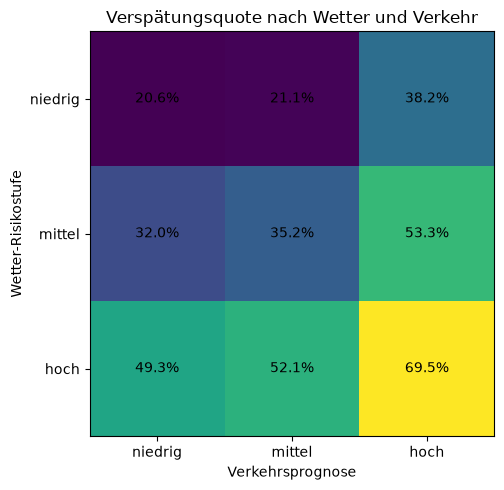

In [293]:
## 3×3-Matrix visualisieren
import matplotlib.pyplot as plt
import numpy as np

heatmap_data = (
    matrix_3x3
    .pivot(
        index="wetter_risikostufe",
        columns="verkehr_prognose",
        values="verspaetungsquote"
    )
    .reindex(
        index=["niedrig", "mittel", "hoch"],
        columns=["niedrig", "mittel", "hoch"]
    )
)

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(heatmap_data.values)

ax.set_xticks(range(3))
ax.set_xticklabels(["niedrig", "mittel", "hoch"])

ax.set_yticks(range(3))
ax.set_yticklabels(["niedrig", "mittel", "hoch"])

ax.set_xlabel("Verkehrsprognose")
ax.set_ylabel("Wetter-Risikostufe")
ax.set_title("Verspätungsquote nach Wetter und Verkehr")

for i in range(3):
    for j in range(3):
        ax.text(
            j, i,
            f"{heatmap_data.iloc[i, j]:.1f}%",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [294]:
## Chi²-Test
from scipy.stats import chi2_contingency

df_test = df[df["wetter_risikostufe"] != "unbekannt"].copy()

df_test["wetter_verkehr_3x3"] = (
    df_test["wetter_risikostufe"] + " | " +
    df_test["verkehr_prognose"]
)

kontingenz = pd.crosstab(
    df_test["wetter_verkehr_3x3"],
    df_test["verspaetet"]
)

chi2, p, dof, expected = chi2_contingency(kontingenz)

print(kontingenz)
print()
print(f"Chi²: {chi2:.2f}")
print(f"p-Wert: {p:.6g}")
print(f"Freiheitsgrade: {dof}")

verspaetet             0    1
wetter_verkehr_3x3           
hoch | hoch           73  166
hoch | mittel        226  246
hoch | niedrig       227  221
mittel | hoch        203  232
mittel | mittel      609  331
mittel | niedrig     639  301
niedrig | hoch      1013  627
niedrig | mittel    2598  695
niedrig | niedrig   2682  695

Chi²: 815.91
p-Wert: 7.65866e-171
Freiheitsgrade: 8


In [295]:
## Cramér's V
import numpy as np

n = kontingenz.to_numpy().sum()
r, k = kontingenz.shape

cramers_v = np.sqrt(
    chi2 / (n * min(r - 1, k - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.263


Die Kombination aus Wetter- und Verkehrslage zeigt einen statistisch signifikanten Zusammenhang mit Verspätungen. Cramér’s V von 0,263 weist dabei auf einen moderaten Zusammenhang hin.

In [296]:
df_4 = df.copy()

df_4["schlechtes_wetter"] = df_4["wetter"].isin(
    ["regen", "schnee", "sturm"]
).astype(int)

df_4["hoher_verkehr"] = (
    df_4["verkehr_prognose"] == "hoch"
).astype(int)

df_4["wetter_verkehr_gruppe"] = (
    df_4["schlechtes_wetter"].astype(str)
    + df_4["hoher_verkehr"].astype(str)
)

print(df_4["wetter_verkehr_gruppe"].value_counts())

wetter_verkehr_gruppe
00    6851
10    2800
01    1699
11     674
Name: count, dtype: int64


In [297]:
## Cramér’s V
kontingenz_4 = pd.crosstab(
    df_4["wetter_verkehr_gruppe"],
    df_4["verspaetet"]
)

chi2_4, p_4, dof_4, expected_4 = chi2_contingency(kontingenz_4)

n_4 = kontingenz_4.to_numpy().sum()
r_4, k_4 = kontingenz_4.shape

cramers_v_4 = np.sqrt(
    chi2_4 / (n_4 * min(r_4 - 1, k_4 - 1))
)

print(kontingenz_4)
print()
print(f"Chi²: {chi2_4:.2f}")
print(f"p-Wert: {p_4:.6g}")
print(f"Cramér's V: {cramers_v_4:.3f}")

verspaetet                0     1
wetter_verkehr_gruppe            
00                     5419  1432
01                     1044   655
10                     1701  1099
11                      276   398

Chi²: 716.59
p-Wert: 5.31723e-155
Cramér's V: 0.244


In [298]:
df["wetter_verkehr_3x3"] = (
    df["wetter_risikostufe"] + " | " + df["verkehr_prognose"]
)

print(df["wetter_verkehr_3x3"].value_counts())

wetter_verkehr_3x3
niedrig | niedrig      3377
niedrig | mittel       3293
niedrig | hoch         1640
mittel | niedrig        940
mittel | mittel         940
hoch | mittel           472
hoch | niedrig          448
mittel | hoch           435
hoch | hoch             239
unbekannt | mittel       96
unbekannt | niedrig      85
unbekannt | hoch         59
Name: count, dtype: int64


### Prüfen ob unsere neuen Features zu stark redundant miteinander sind

In [299]:
df[
    [
        "strecke_km",
        "paket_gewicht_kg",
        "versprochene_zustellung_stunden",
        "km_pro_stunde",
        "hohes_risiko",
        "enge_lieferung_hoher_verkehr",
        "verspaetet"
    ]
].corr().round(2)

,strecke_km,paket_gewicht_kg,versprochene_zustellung_stunden,km_pro_stunde,hohes_risiko,enge_lieferung_hoher_verkehr,verspaetet
strecke_km,1.00,0.00,0.01,0.63,0.00,0.22,0.16
paket_gewicht_kg,0.00,1.00,-0.00,0.00,-0.02,-0.01,0.01
versprochene_zustellung_stunden,0.01,-0.00,1.00,-0.43,0.01,-0.19,-0.11
km_pro_stunde,0.63,0.00,-0.43,1.00,0.00,0.26,0.18
hohes_risiko,0.00,-0.02,0.01,0.00,1.00,0.23,0.16
enge_lieferung_hoher_verkehr,0.22,-0.01,-0.19,0.26,0.23,1.00,0.15
verspaetet,0.16,0.01,-0.11,0.18,0.16,0.15,1.00


- strecke_km ↔ km_pro_stunde = 0,63 → relativ starker Zusammenhang, aber nachvollziehbar, weil strecke_km Teil der Berechnung von km_pro_stunde ist.
- versprochene_zustellung_stunden ↔ km_pro_stunde = −0,43 → ebenfalls logisch: mehr verfügbare Stunden senken km_pro_stunde.
- Die übrigen Zusammenhänge liegen deutlich niedriger.

In [300]:
# neuer Datensatz
df_ml = df[
    [
        "abhol_zeit_uhr",
        "strecke_km",
        "paket_groesse",
        "paket_gewicht_kg",
        "fahrzeug_typ",
        "wetter",
        "verkehr_prognose",
        "versprochene_zustellung_stunden",
        "wochentag_neu",
        "strecken_kategorie",
        "hohes_risiko",
        "km_pro_stunde",
        "enge_lieferung_hoher_verkehr",
        "wetter_risikostufe",
        "wetter_verkehr_3x3",
        "verspaetet"
    ]
].copy()

df_ml.head(20)

,abhol_zeit_uhr,strecke_km,paket_groesse,paket_gewicht_kg,fahrzeug_typ,wetter,verkehr_prognose,versprochene_zustellung_stunden,wochentag_neu,strecken_kategorie,hohes_risiko,km_pro_stunde,enge_lieferung_hoher_verkehr,wetter_risikostufe,wetter_verkehr_3x3,verspaetet
0,17:00:00,31,Mittel,12.9,Transporter,sonnig,hoch,24,Mi,kurz,0,1.291667,0,niedrig,niedrig | hoch,0
1,08:00:00,170,Mittel,15.0,Lkw (Gross),regen,hoch,24,Di,lang,1,7.083333,1,mittel,mittel | hoch,1
2,15:00:00,85,Klein,4.5,Transporter,sonnig,niedrig,24,Fr,mittel,0,3.541667,0,niedrig,niedrig | niedrig,0
3,14:00:00,28,Klein,4.9,Transporter,bewoelkt,mittel,8,Di,kurz,0,3.500000,0,niedrig,niedrig | mittel,0
4,15:00:00,49,Klein,1.6,Lkw (Klein),bewoelkt,niedrig,8,Di,kurz,0,6.125000,0,niedrig,niedrig | niedrig,0
5,12:00:00,170,Gross,22.8,Transporter,bewoelkt,mittel,24,So,lang,0,7.083333,0,niedrig,niedrig | mittel,0
6,13:00:00,187,Gross,51.1,Lkw (Klein),regen,niedrig,8,So,lang,0,23.375000,0,mittel,mittel | niedrig,0
7,19:00:00,86,Mittel,15.6,Lkw (Klein),sonnig,niedrig,48,Mo,mittel,0,1.791667,0,niedrig,niedrig | niedrig,0
8,07:00:00,105,Mittel,19.6,Transporter,regen,mittel,24,Fr,lang,0,4.375000,0,mittel,mittel | mittel,0
9,09:00:00,3,Gross,19.2,Lkw (Klein),bewoelkt,niedrig,4,Di,sehr_kurz,0,0.750000,0,niedrig,niedrig | niedrig,0


In [301]:
print(df_ml.shape)
print(df_ml.columns.tolist())
print(df_ml.dtypes)
print("\nFehlende Werte:")
print(df_ml.isna().sum())

print("\nDuplizierte Spaltennamen:")
print(df_ml.columns[df_ml.columns.duplicated()].tolist())

(12024, 16)
['abhol_zeit_uhr', 'strecke_km', 'paket_groesse', 'paket_gewicht_kg', 'fahrzeug_typ', 'wetter', 'verkehr_prognose', 'versprochene_zustellung_stunden', 'wochentag_neu', 'strecken_kategorie', 'hohes_risiko', 'km_pro_stunde', 'enge_lieferung_hoher_verkehr', 'wetter_risikostufe', 'wetter_verkehr_3x3', 'verspaetet']
abhol_zeit_uhr                          str
strecke_km                            int64
paket_groesse                           str
paket_gewicht_kg                    float64
fahrzeug_typ                            str
wetter                                  str
verkehr_prognose                        str
versprochene_zustellung_stunden       int64
wochentag_neu                           str
strecken_kategorie                 category
hohes_risiko                          int64
km_pro_stunde                       float64
enge_lieferung_hoher_verkehr          int64
wetter_risikostufe                      str
wetter_verkehr_3x3                      str
verspaetet     

In [302]:
df_ml.to_csv(
    "lieferdaten_tableau.csv",
    index=False,
    sep=",",
    encoding="utf-8-sig"
)

print("Gespeichert:", df_ml.shape)

Gespeichert: (12024, 16)


In [303]:
df_ml.to_csv(
    "lieferdaten_tableau.tsv",
    index=False,
    sep="\t",
    encoding="utf-8-sig"
)

In [304]:
# Finalen ML-Datensatz erstellen
df_ml = df[
    [
        "abhol_zeit_uhr",
        "strecke_km",
        "paket_groesse",
        "paket_gewicht_kg",
        "fahrzeug_typ",
        "wetter",
        "verkehr_prognose",
        "versprochene_zustellung_stunden",
        "wochentag_neu",
        "strecken_kategorie",
        "hohes_risiko",
        "km_pro_stunde",
        "enge_lieferung_hoher_verkehr",
        "wetter_risikostufe",
        "wetter_verkehr_3x3",
        "verspaetet"
    ]
].copy()

# Neue CSV speichern – Originaldatei bleibt unverändert
df_ml.to_csv("lieferdaten_ml_vorbereitet.csv", index=False)

print("Dimension:", df_ml.shape)
print("\nSpalten:")
print(df_ml.columns.tolist())

Dimension: (12024, 16)

Spalten:
['abhol_zeit_uhr', 'strecke_km', 'paket_groesse', 'paket_gewicht_kg', 'fahrzeug_typ', 'wetter', 'verkehr_prognose', 'versprochene_zustellung_stunden', 'wochentag_neu', 'strecken_kategorie', 'hohes_risiko', 'km_pro_stunde', 'enge_lieferung_hoher_verkehr', 'wetter_risikostufe', 'wetter_verkehr_3x3', 'verspaetet']
